# GR-Prediction Frame-Rate S6 - CREPE-style Discretized Output

Train a **frame-rate S6/selective-state-space model** to estimate gain reduction from dry audio. This follows the discretized LSTM workflow, but swaps the recurrent block for the S6 selective scan from the comparative-study reference.

## Architecture

```
dry audio [B,1,T]
  -> strided conv encoder -> features [B,C,T/hop]
    -> linear projection -> [B,T/hop,D]
      -> S6 selective SSM -> [B,T/hop,D]
        -> tanh dense -> logits [B,151,T/hop]
          -> sigmoid + local weighted avg -> GR_db [B,1,T/hop]
```

The notebook reuses:

- `03_initial_GR_pred/gr_dataset.py` for precomputed GR data loading.
- `src.gr_s6` for the PyTorch S6 layer, discretized-bin helpers, and Lightning system.

This notebook is intended for **Google Colab**. It mounts Google Drive, auto-locates both the dataset and this repo folder, imports the shared project modules from Drive, caches audio/GR curves to the Colab SSD, and saves checkpoints back to Drive.

Before running, make sure the repo folder containing `src/gr_s6.py` and `03_initial_GR_pred/gr_dataset.py` is available somewhere under `/content/drive`, and that precomputed GR curves exist under `Diff-SSL-G-Comp/gr_curves/<SETTING>/`.

In [1]:
# 0. Install Colab dependencies

!pip install -q lightning torchmetrics soundfile

In [2]:
# 1. Mount Google Drive and locate dataset

import glob
import os
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ModuleNotFoundError:
    drive = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive", force_remount=False)

DRIVE_DATA_ROOT: str | None = None
SETTING = "threshold_-4_attack_1_release_0.4_ratio_10"


def _find_dataset_root() -> str | None:
    if IN_COLAB:
        patterns = [
            "/content/drive/*/*/*/Diff-SSL-G-Comp",
            "/content/drive/*/*/Diff-SSL-G-Comp",
            "/content/drive/*/Diff-SSL-G-Comp",
        ]
    else:
        patterns = ["/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"]

    candidates: list[str] = []
    for pattern in patterns:
        candidates.extend(glob.glob(pattern))

    for candidate in candidates:
        if (
            os.path.isdir(os.path.join(candidate, "processed_normalized"))
            and os.path.isdir(os.path.join(candidate, "processed_ground_truth"))
        ):
            return candidate
    return None


if DRIVE_DATA_ROOT is None:
    DRIVE_DATA_ROOT = _find_dataset_root()

if DRIVE_DATA_ROOT is None or not os.path.isdir(DRIVE_DATA_ROOT):
    raise AssertionError(
        "Dataset folder not found. Set DRIVE_DATA_ROOT to the full "
        "'/content/drive/.../Diff-SSL-G-Comp' path and re-run this cell."
    )

DATA_ROOT = Path(DRIVE_DATA_ROOT)
dry_dir = DATA_ROOT / "processed_normalized"
wet_dir = DATA_ROOT / "processed_ground_truth" / SETTING
gr_dir = DATA_ROOT / "gr_curves" / SETTING

assert dry_dir.is_dir(), f"Missing dry folder: {dry_dir}"
assert wet_dir.is_dir(), f"Missing wet folder: {wet_dir}"
assert gr_dir.is_dir(), f"Missing precomputed GR folder: {gr_dir}"

RUNS_DIR = DATA_ROOT.parent / "gr_pred_runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset root : {DATA_ROOT}")
print(f"Setting      : {SETTING}")
print(f"Dry files    : {len(list(dry_dir.glob('*.wav')))}")
print(f"Wet files    : {len(list(wet_dir.glob('*.wav')))}")
print(f"GR curves    : {len(list(gr_dir.glob('*.pt')))}")
print(f"Runs dir     : {RUNS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset root : /content/drive/Othercomputers/MacBook Air/data/Diff-SSL-G-Comp
Setting      : threshold_-4_attack_1_release_0.4_ratio_10
Dry files    : 175
Wet files    : 10
GR curves    : 10
Runs dir     : /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs


In [3]:
# 1b. Cache dataset to Colab SSD

import shutil
import time

LOCAL_DATA_ROOT = Path("/content/Diff-SSL-G-Comp")
USE_LOCAL_CACHE = IN_COLAB


def _remount_drive():
    if not IN_COLAB:
        return
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    drive.mount("/content/drive", force_remount=True)


def _robust_copy(src: Path, dst: Path, max_retries: int = 5):
    for attempt in range(1, max_retries + 1):
        try:
            with open(src, "rb") as fsrc, open(dst, "wb") as fdst:
                shutil.copyfileobj(fsrc, fdst, length=1024 * 1024)
            return
        except OSError as exc:
            print(f"  [retry {attempt}/{max_retries}] {src.name}: {exc}")
            try:
                dst.unlink(missing_ok=True)
            except Exception:
                pass
            time.sleep(2 * attempt)
            if "Transport endpoint" in str(exc) or getattr(exc, "errno", None) in (5, 107):
                _remount_drive()
    raise RuntimeError(f"Failed to copy {src} after {max_retries} retries")


def _mirror_pair(src: Path, dst: Path, label: str, index: int, total: int):
    need_copy = not dst.exists() or dst.stat().st_size != src.stat().st_size
    if need_copy:
        _robust_copy(src, dst)
    suffix = " [skip]" if not need_copy else ""
    print(f"  {label}: {index}/{total} ({src.name}){suffix}")


if USE_LOCAL_CACHE:
    local_dry = LOCAL_DATA_ROOT / "processed_normalized"
    local_gr = LOCAL_DATA_ROOT / "gr_curves" / SETTING
    local_dry.mkdir(parents=True, exist_ok=True)
    local_gr.mkdir(parents=True, exist_ok=True)

    pt_files = sorted(gr_dir.glob("*.pt"))
    songs = [path.stem for path in pt_files]
    print(f"Found {len(songs)} songs with GR curves for '{SETTING}':")
    for song in songs:
        print(f"  - {song}")

    print(f"\nCopying {len(songs)} dry files ...")
    for index, song in enumerate(songs, 1):
        dry_src = dry_dir / f"{song}_UnmasteredWAV.wav"
        dry_dst = local_dry / f"{song}_UnmasteredWAV.wav"
        if not dry_src.exists():
            print(f"  WARNING: no dry file for '{song}', skipping")
            continue
        _mirror_pair(dry_src, dry_dst, "dry", index, len(songs))

    print(f"\nCopying {len(pt_files)} GR curve files ...")
    for index, pt_src in enumerate(pt_files, 1):
        _mirror_pair(pt_src, local_gr / pt_src.name, "gr", index, len(pt_files))

    DATA_ROOT = LOCAL_DATA_ROOT
    print(f"\nUsing local cache: {DATA_ROOT}")
else:
    print(f"Reading directly from: {DATA_ROOT}")

Found 10 songs with GR curves for 'threshold_-4_attack_1_release_0.4_ratio_10':
  - Air
  - AncoraQui
  - BackroomInTulsa
  - Borderline
  - Ecstasy
  - Electrvm
  - LivingLie
  - NosPalpitants
  - OpenFire
  - SongForJohn

Copying 10 dry files ...
  dry: 1/10 (Air_UnmasteredWAV.wav) [skip]
  dry: 2/10 (AncoraQui_UnmasteredWAV.wav) [skip]
  dry: 3/10 (BackroomInTulsa_UnmasteredWAV.wav) [skip]
  dry: 4/10 (Borderline_UnmasteredWAV.wav) [skip]
  dry: 5/10 (Ecstasy_UnmasteredWAV.wav) [skip]
  dry: 6/10 (Electrvm_UnmasteredWAV.wav) [skip]
  dry: 7/10 (LivingLie_UnmasteredWAV.wav) [skip]
  dry: 8/10 (NosPalpitants_UnmasteredWAV.wav) [skip]
  dry: 9/10 (OpenFire_UnmasteredWAV.wav) [skip]
  dry: 10/10 (SongForJohn_UnmasteredWAV.wav) [skip]

Copying 10 GR curve files ...
  gr: 1/10 (Air.pt) [skip]
  gr: 2/10 (AncoraQui.pt) [skip]
  gr: 3/10 (BackroomInTulsa.pt) [skip]
  gr: 4/10 (Borderline.pt) [skip]
  gr: 5/10 (Ecstasy.pt) [skip]
  gr: 6/10 (Electrvm.pt) [skip]
  gr: 7/10 (LivingLie.pt) [ski

In [4]:
# 2. Import shared project code

import json
import os
import re
import sys
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import lightning as pl

warnings.filterwarnings("ignore", category=UserWarning)

try:
    from google.colab import drive as _drive
    IN_COLAB = True
except ModuleNotFoundError:
    _drive = None
    try:
        IN_COLAB
    except NameError:
        IN_COLAB = False

# Make this cell safe to run by itself after a runtime restart. In Colab,
# /content/drive can exist before Drive is actually mounted, so check for the
# mount contents instead of only the directory.
if IN_COLAB:
    drive_mount_points = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/Othercomputers"),
        Path("/content/drive/Shareddrives"),
    ]
    if not any(path.exists() for path in drive_mount_points):
        _drive.mount("/content/drive", force_remount=False)

# Set this manually if the bounded auto-discovery misses your Drive layout.
DRIVE_REPO_ROOT: str | None = None
REPO_DIRNAME = "Virtual-Analogue-Compressor-Modelling"


def _is_repo_root(path: Path) -> bool:
    return (
        (path / "03_initial_GR_pred" / "gr_dataset.py").is_file()
        and (path / "src" / "gr_s6.py").is_file()
    )


def _unique_existing(paths: list[Path]) -> list[Path]:
    seen: set[str] = set()
    out: list[Path] = []
    for path in paths:
        key = str(path)
        if key not in seen and path.exists():
            seen.add(key)
            out.append(path)
    return out


def _bounded_repo_candidates() -> list[Path]:
    candidates: list[Path] = []

    if DRIVE_REPO_ROOT:
        candidates.append(Path(DRIVE_REPO_ROOT).expanduser())

    candidates.extend([Path.cwd(), Path.cwd().parent, Path.cwd() / REPO_DIRNAME])

    # The dataset cell keeps DRIVE_DATA_ROOT pointing at Drive even if DATA_ROOT
    # was changed to /content/Diff-SSL-G-Comp by the cache cell.
    drive_data_root = globals().get("DRIVE_DATA_ROOT")
    if drive_data_root:
        data_path = Path(drive_data_root)
        for parent in [data_path.parent, *data_path.parents]:
            candidates.extend([
                parent / REPO_DIRNAME,
                parent / "AllCode" / "thesis" / REPO_DIRNAME,
                parent / "thesis" / REPO_DIRNAME,
            ])

    if Path("/content/drive").exists():
        # Shallow checks only. Avoid recursive Drive globs because they can take
        # minutes on synced Computer folders.
        drive_roots = [
            Path("/content/drive/MyDrive"),
            Path("/content/drive/Othercomputers"),
            Path("/content/drive/Computers"),
            Path("/content/drive/Shareddrives"),
        ]
        for root in drive_roots:
            candidates.append(root / REPO_DIRNAME)
            for child in list(root.glob("*"))[:50] if root.exists() else []:
                candidates.extend([
                    child / REPO_DIRNAME,
                    child / "AllCode" / "thesis" / REPO_DIRNAME,
                    child / "thesis" / REPO_DIRNAME,
                    child / "AllCode" / REPO_DIRNAME,
                ])

    return _unique_existing(candidates)


def _find_repo_root() -> tuple[Path | None, list[str]]:
    candidates = _bounded_repo_candidates()
    searched = [str(path) for path in candidates]
    for candidate in candidates:
        if _is_repo_root(candidate):
            return candidate, searched
    return None, searched


PROJECT_ROOT, searched_paths = _find_repo_root()
USING_SELF_CONTAINED_FALLBACK = PROJECT_ROOT is None

if not USING_SELF_CONTAINED_FALLBACK:
    NOTEBOOK_DIR = PROJECT_ROOT / "03_initial_GR_pred"
    for path in (str(PROJECT_ROOT), str(NOTEBOOK_DIR)):
        if path not in sys.path:
            sys.path.insert(0, path)
    os.chdir(NOTEBOOK_DIR)

    from gr_dataset import PrecomputedGRDataModule
    from src.dsp_torch import GR_DB_MAX, GR_DB_MIN, RMS_WINDOW
    from src.gr_s6 import (
        GR_BIN_RESOLUTION,
        GR_NUM_BINS,
        DiscretizedGRPredictionSystem,
        FrameRateS6GR,
        build_frame_rate_s6_from_hparams,
    )
    print(f"Project root : {PROJECT_ROOT}")
    print(f"Notebook dir : {NOTEBOOK_DIR}")
else:
    print("Repository folder not found. Continuing with self-contained fallback definitions.")
    print("Checked:\n- " + "\n- ".join(searched_paths[-20:]))

    import math
    from typing import Any, Optional

    import soundfile as sf
    import torchaudio
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset

    GR_DB_MIN = -30.0
    GR_DB_MAX = 0.0
    RMS_WINDOW = 1024
    GR_NUM_BINS = 151
    GR_BIN_RESOLUTION = 0.2

    def gr_bin_centers(device=None, dtype=None):
        return torch.linspace(GR_DB_MIN, GR_DB_MAX, GR_NUM_BINS, device=device, dtype=dtype)

    def gr_db_to_soft_target(gr_db: torch.Tensor, sigma_bins: float = 2.0) -> torch.Tensor:
        centers = gr_bin_centers(device=gr_db.device, dtype=gr_db.dtype)
        diff = gr_db - centers.view(1, -1, 1)
        sigma_db = sigma_bins * GR_BIN_RESOLUTION
        return torch.exp(-0.5 * (diff / sigma_db) ** 2)

    def logits_to_local_avg_db(logits: torch.Tensor, window: int = 5) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        centers = gr_bin_centers(device=logits.device, dtype=logits.dtype)
        peak = probs.argmax(dim=1)
        batch, num_bins, frames = probs.shape
        bin_idx = torch.arange(num_bins, device=logits.device).view(1, num_bins, 1).expand(batch, num_bins, frames)
        lo = (peak.unsqueeze(1) - window).clamp(min=0)
        hi = (peak.unsqueeze(1) + window + 1).clamp(max=num_bins)
        mask = (bin_idx >= lo) & (bin_idx < hi)
        masked_probs = probs * mask
        weighted = (masked_probs * centers.view(1, -1, 1)).sum(dim=1, keepdim=True)
        total = masked_probs.sum(dim=1, keepdim=True).clamp(min=1e-8)
        return weighted / total

    class PrecomputedGRDataset(Dataset):
        def __init__(
            self,
            data_root: str,
            settings_folder: str,
            sample_length: int,
            sample_stride: int | None = None,
            sample_rate: int = 44100,
            random_crop: bool = False,
            samples: list[dict] | None = None,
            _gr_cache: dict | None = None,
            cache_dry: bool = False,
            _dry_cache: dict | None = None,
        ):
            self.data_root = data_root
            self.settings_folder = settings_folder
            self.sample_length = sample_length
            self.sample_stride = sample_stride or sample_length
            self.sample_rate = sample_rate
            self.random_crop = random_crop
            self.cache_dry = cache_dry

            if samples is not None:
                self.samples = samples
                self._gr_cache = _gr_cache or {}
                self._dry_cache = _dry_cache or {}
                return

            dry_dir = Path(data_root) / "processed_normalized"
            gr_dir = Path(data_root) / "gr_curves" / settings_folder
            if not gr_dir.is_dir():
                raise FileNotFoundError(f"No pre-computed GR curves at {gr_dir}")

            dry_lookup = {
                p.name.replace("_UnmasteredWAV.wav", ""): p
                for p in sorted(dry_dir.glob("*_UnmasteredWAV.wav"))
            }

            self._gr_cache = {}
            for pt_file in sorted(gr_dir.glob("*.pt")):
                song = pt_file.stem
                if song in dry_lookup:
                    rec = torch.load(pt_file, weights_only=False)
                    self._gr_cache[song] = rec["gr_db"]

            self._dry_cache = {}
            if cache_dry:
                print("Caching dry audio files in RAM...")
                for song in sorted(self._gr_cache):
                    dry_tensor, sr = sf.read(dry_lookup[song], dtype="float32", always_2d=True)
                    dry_tensor = torch.from_numpy(dry_tensor.T)
                    if sr != sample_rate:
                        dry_tensor = torchaudio.functional.resample(dry_tensor, sr, sample_rate)
                    if dry_tensor.shape[0] > 1:
                        dry_tensor = dry_tensor.mean(dim=0, keepdim=True)
                    self._dry_cache[song] = dry_tensor

            self.samples = []
            for song in sorted(self._gr_cache):
                n_frames = int(self._gr_cache[song].shape[-1])
                dry_path = str(dry_lookup[song])
                if sample_length == -1:
                    self.samples.append({"song": song, "dry": dry_path, "offset": 0, "frames": n_frames, "n_frames": n_frames})
                    continue
                if n_frames < sample_length:
                    continue
                max_start = n_frames - sample_length
                for offset in range(0, max_start + 1, self.sample_stride):
                    self.samples.append({"song": song, "dry": dry_path, "offset": offset, "frames": sample_length, "n_frames": n_frames})
                if self.samples[-1]["offset"] != max_start:
                    self.samples.append({"song": song, "dry": dry_path, "offset": max_start, "frames": sample_length, "n_frames": n_frames})

            cache_mb = sum(t.numel() * 4 for t in self._gr_cache.values()) / 1024 / 1024
            print(f"PrecomputedGRDataset: {len(self._gr_cache)} songs, {len(self.samples)} crops, GR cache={cache_mb:.0f} MB")

        def with_samples(self, samples: list[dict], random_crop: bool):
            return PrecomputedGRDataset(
                self.data_root, self.settings_folder, self.sample_length, self.sample_stride,
                self.sample_rate, random_crop, samples, self._gr_cache, self.cache_dry, self._dry_cache,
            )

        def __len__(self):
            return len(self.samples)

        def _crop_offset(self, sample: dict) -> int:
            if self.sample_length == -1 or not self.random_crop:
                return sample["offset"]
            max_start = max(0, sample["n_frames"] - sample["frames"])
            return int(torch.randint(0, max_start + 1, ()).item()) if max_start else 0

        def __getitem__(self, idx: int):
            sample = self.samples[idx]
            offset = self._crop_offset(sample)
            frames = sample["frames"] if self.sample_length != -1 else sample["n_frames"]
            if self.cache_dry and sample["song"] in self._dry_cache:
                dry = self._dry_cache[sample["song"]][..., offset:offset + frames]
            else:
                dry_np, sr = sf.read(sample["dry"], start=offset, stop=offset + frames, dtype="float32", always_2d=True)
                dry = torch.from_numpy(dry_np.T)
                if sr != self.sample_rate:
                    dry = torchaudio.functional.resample(dry, sr, self.sample_rate)
                if dry.shape[0] > 1:
                    dry = dry.mean(dim=0, keepdim=True)
            gr_db = self._gr_cache[sample["song"]][..., offset:offset + frames]
            min_len = min(dry.shape[-1], gr_db.shape[-1])
            return dry[..., :min_len], gr_db[..., :min_len]

    class PrecomputedGRDataModule(pl.LightningDataModule):
        def __init__(self, data_root: str, settings_folder: str, sample_length: int, sample_stride: int | None = None,
                     sample_rate: int = 44100, train_split: float = 0.8, batch_size: int = 8,
                     num_workers: int = 2, cache_dry: bool = False):
            super().__init__()
            self.data_root = data_root
            self.settings_folder = settings_folder
            self.sample_length = sample_length
            self.sample_stride = sample_stride or sample_length
            self.sample_rate = sample_rate
            self.train_split = train_split
            self.batch_size = batch_size
            self.num_workers = num_workers
            self.cache_dry = cache_dry

        def setup(self, stage: Optional[str] = None):
            full = PrecomputedGRDataset(
                self.data_root, self.settings_folder, self.sample_length, self.sample_stride,
                self.sample_rate, random_crop=False, cache_dry=self.cache_dry,
            )
            songs = sorted({s["song"] for s in full.samples})
            if len(songs) < 2:
                raise ValueError("Need >= 2 songs for train/val split.")
            generator = torch.Generator().manual_seed(42)
            perm = torch.randperm(len(songs), generator=generator).tolist()
            n_train = min(max(1, int(len(songs) * self.train_split)), len(songs) - 1)
            train_songs = {songs[i] for i in perm[:n_train]}
            val_songs = set(songs) - train_songs
            self.train_dataset = full.with_samples([s for s in full.samples if s["song"] in train_songs], random_crop=True)
            self.val_dataset = full.with_samples([s for s in full.samples if s["song"] in val_songs], random_crop=False)
            print(f"Train: {len(self.train_dataset)} crops from {len(train_songs)} songs {sorted(train_songs)}")
            print(f"Val:   {len(self.val_dataset)} crops from {len(val_songs)} songs {sorted(val_songs)}")

        def train_dataloader(self):
            return DataLoader(
                self.train_dataset, batch_size=self.batch_size, shuffle=True,
                num_workers=self.num_workers, pin_memory=True, drop_last=True,
                persistent_workers=self.num_workers > 0,
            )

        def val_dataloader(self):
            return DataLoader(
                self.val_dataset, batch_size=self.batch_size, shuffle=False,
                num_workers=self.num_workers, pin_memory=True,
                persistent_workers=self.num_workers > 0,
            )

    def selective_scan(u, delta, a, b, c, d, last_state=None, stateful=False):
        d_a = torch.einsum("bld,dn->bldn", delta, a)
        d_b_u = torch.einsum("bld,bld,bln->bldn", delta, u, b)
        d_a_cumsum = torch.cat([torch.zeros_like(d_a[:, :1]), d_a[:, 1:]], dim=1)
        d_a_cumsum = torch.exp(torch.cumsum(d_a_cumsum, dim=1))
        x = torch.cumsum(d_b_u / (d_a_cumsum + 1e-12), dim=1) * d_a_cumsum
        if stateful and last_state is not None:
            x = x + torch.exp(torch.cumsum(d_a, dim=1)) * last_state.unsqueeze(1)
        y = torch.einsum("bldn,bln->bld", x, c)
        return y + u * d.view(1, 1, -1), x[:, -1]

    class S6Layer(nn.Module):
        def __init__(self, model_input_dims: int, model_states: int, stateful: bool = False, fixed_out_projection: bool = True):
            super().__init__()
            self.model_input_dims = model_input_dims
            self.model_states = model_states
            self.stateful = stateful
            self.delta_t_rank = math.ceil(model_input_dims / 2)
            self.x_projection = nn.Linear(model_input_dims, self.delta_t_rank + 2 * model_states, bias=False)
            self.delta_t_projection = nn.Linear(self.delta_t_rank, model_input_dims)
            a = torch.arange(1, model_states + 1, dtype=torch.float32).view(1, model_states).repeat(model_input_dims, 1)
            self.a_log = nn.Parameter(torch.log(a))
            self.d = nn.Parameter(torch.ones(model_input_dims))
            self.out_projection = nn.Linear(model_input_dims, model_input_dims)
            if fixed_out_projection:
                for param in self.out_projection.parameters():
                    param.requires_grad = False
            self.register_buffer("state", torch.empty(0), persistent=False)

        def reset_states(self):
            self.state = torch.empty(0, device=self.state.device)

        def _last_state(self, x):
            if not self.stateful:
                return None
            expected = (x.shape[0], self.model_input_dims, self.model_states)
            if tuple(self.state.shape) != expected or self.state.device != x.device:
                self.state = torch.zeros(expected, device=x.device, dtype=x.dtype)
            return self.state

        def forward(self, x):
            a = -torch.exp(self.a_log.float()).to(dtype=x.dtype)
            d = self.d.to(dtype=x.dtype)
            x_dbl = self.x_projection(x)
            delta, b, c = torch.split(x_dbl, [self.delta_t_rank, self.model_states, self.model_states], dim=-1)
            delta = F.softplus(self.delta_t_projection(delta))
            y, next_state = selective_scan(x, delta, a, b, c, d, self._last_state(x), self.stateful)
            if self.stateful:
                self.state = next_state.detach()
            return self.out_projection(y)

    class FrameRateS6GR(nn.Module):
        def __init__(self, hop_size=256, encoder_channels=32, model_dim=32, state_dim=16,
                     num_s6_layers=1, dropout=0.0, num_bins=GR_NUM_BINS,
                     stateful=False, fixed_out_projection=True):
            super().__init__()
            self.hop_size = hop_size
            self.num_bins = num_bins
            kernel_size = hop_size * 2
            self.encoder = nn.Sequential(
                nn.Conv1d(1, encoder_channels, kernel_size, stride=hop_size, padding=kernel_size // 2),
                nn.PReLU(encoder_channels),
                nn.Conv1d(encoder_channels, encoder_channels, 3, padding=1),
                nn.PReLU(encoder_channels),
            )
            self.input_projection = nn.Linear(encoder_channels, model_dim)
            self.s6_layers = nn.ModuleList([
                S6Layer(model_dim, state_dim, stateful, fixed_out_projection)
                for _ in range(num_s6_layers)
            ])
            self.post_s6 = nn.ModuleList([
                nn.Sequential(nn.Linear(model_dim, model_dim), nn.Tanh(), nn.Dropout(dropout))
                for _ in range(num_s6_layers)
            ])
            self.head = nn.Sequential(nn.Linear(model_dim, max(1, model_dim // 2)), nn.ReLU(), nn.Linear(max(1, model_dim // 2), num_bins))

        def forward(self, x):
            h = self.input_projection(self.encoder(x).transpose(1, 2))
            for s6_layer, post_layer in zip(self.s6_layers, self.post_s6):
                h = post_layer(s6_layer(h))
            return self.head(h).transpose(1, 2)

        def to_db(self, logits, samples=None):
            db = logits_to_local_avg_db(logits)
            if samples is not None:
                db = F.interpolate(db, size=samples, mode="linear", align_corners=False)
            return db

        def reset_states(self):
            for layer in self.s6_layers:
                layer.reset_states()

    class DiscretizedGRPredictionSystem(pl.LightningModule):
        def __init__(self, model: nn.Module, lr=1e-3, sigma_bins=2.0, warmup_frames=4,
                     lr_patience=20, min_lr=1e-6, local_avg_window=5):
            super().__init__()
            self.save_hyperparameters(ignore=["model"])
            self.model = model
            self.lr = lr
            self.sigma_bins = sigma_bins
            self.warmup_frames = warmup_frames
            self.lr_patience = lr_patience
            self.min_lr = min_lr
            self.local_avg_window = local_avg_window

        def forward(self, x):
            return self.model(x)

        def _step(self, batch, mode):
            dry, gr_db = batch
            gr_db = gr_db.clamp(GR_DB_MIN, GR_DB_MAX)
            if hasattr(self.model, "reset_states"):
                self.model.reset_states()
            logits = self(dry)
            frames = logits.shape[-1]
            gr_db_frames = F.adaptive_avg_pool1d(gr_db, frames)
            soft_target = gr_db_to_soft_target(gr_db_frames, sigma_bins=self.sigma_bins)
            warmup = min(self.warmup_frames, max(0, frames - 1))
            if warmup:
                logits = logits[..., warmup:]
                soft_target = soft_target[..., warmup:]
                gr_db_frames = gr_db_frames[..., warmup:]
            loss = F.binary_cross_entropy_with_logits(logits, soft_target)
            with torch.no_grad():
                pred_db = logits_to_local_avg_db(logits, window=self.local_avg_window)
                mae_db = F.l1_loss(pred_db, gr_db_frames)
            self.log(f"loss/{mode}", loss, on_step=False, on_epoch=True, prog_bar=True)
            self.log(f"mae_db/{mode}", mae_db, on_step=False, on_epoch=True, prog_bar=True)
            return loss

        def training_step(self, batch, batch_idx):
            return self._step(batch, "train")

        def validation_step(self, batch, batch_idx):
            return self._step(batch, "val")

        def configure_optimizers(self):
            opt = torch.optim.AdamW(self.parameters(), lr=self.lr)
            sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
                opt, mode="min", factor=0.5, patience=self.lr_patience, min_lr=self.min_lr,
            )
            return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "monitor": "loss/val"}}

    def build_frame_rate_s6_from_hparams(hparams: dict[str, Any]) -> FrameRateS6GR:
        cfg = hparams.get("s6", hparams)
        return FrameRateS6GR(
            hop_size=cfg.get("hop_size", 256),
            encoder_channels=cfg.get("encoder_channels", 32),
            model_dim=cfg.get("model_dim", 32),
            state_dim=cfg.get("state_dim", 16),
            num_s6_layers=cfg.get("num_s6_layers", 1),
            dropout=cfg.get("dropout", 0.0),
            num_bins=hparams.get("discretization", {}).get("num_bins", GR_NUM_BINS),
            stateful=cfg.get("stateful", False),
            fixed_out_projection=cfg.get("fixed_out_projection", True),
        )

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
print(f"torch {torch.__version__} | cuda={torch.cuda.is_available()}")

Repository folder not found. Continuing with self-contained fallback definitions.
Checked:
- /content
- /
NVIDIA L4
torch 2.10.0+cu128 | cuda=True


In [5]:
# 3. Dataset and output paths

SAMPLE_RATE = 44100
SAMPLE_LENGTH = 441000   # 10 s
SAMPLE_STRIDE = 110250   # 2.5 s

DATA_ROOT = Path(DATA_ROOT)
RUNS_DIR = Path(RUNS_DIR)
DRY_DIR = DATA_ROOT / "processed_normalized"
GR_DIR = DATA_ROOT / "gr_curves" / SETTING

assert DRY_DIR.is_dir(), f"Missing dry folder: {DRY_DIR}"
assert GR_DIR.is_dir(), f"Missing precomputed GR folder: {GR_DIR}"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset root : {DATA_ROOT}")
print(f"Setting      : {SETTING}")
print(f"Dry files    : {len(list(DRY_DIR.glob('*_UnmasteredWAV.wav')))}")
print(f"GR curves    : {len(list(GR_DIR.glob('*.pt')))}")
print(f"Runs dir     : {RUNS_DIR}")

Dataset root : /content/Diff-SSL-G-Comp
Setting      : threshold_-4_attack_1_release_0.4_ratio_10
Dry files    : 10
GR curves    : 10
Runs dir     : /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs


In [6]:
# 4. Training configuration

RESUME_RUN: str | None = None
RUN_TAG = "s6_v1_discretized_fixed_v3"

# Data
BATCH_SIZE = 8              # S6 selective scan uses [B, frames, D, N] memory.
NUM_WORKERS = 2
CACHE_DRY = False
TRAIN_SPLIT = 0.8

# Optimisation
LR = 3e-4              # was 1e-3 — critical for S6 stability
MAX_EPOCHS = 1000
EARLY_STOP_PATIENCE = 30
LR_PLATEAU_PATIENCE = 20
CKPT_EVERY_N_EPOCHS = 5
SIGMA_BINS = 2.0
WARMUP_FRAMES = 4

# Model
HOP_SIZE = 256
ENCODER_CHANNELS = 32
MODEL_DIM = 64         # was 32
STATE_DIM = 32         # was 16
NUM_S6_LAYERS = 2      # was 1
DROPOUT = 0.0
STATEFUL = False
FIXED_OUT_PROJECTION = True  # Matches the TensorFlow S6 reference.
 
ACCELERATOR = "auto"
PRECISION = "16-mixed" if torch.cuda.is_available() else "32-true"

print(f"Frame rate : {SAMPLE_RATE / HOP_SIZE:.1f} Hz")
print(f"GR bins    : {GR_NUM_BINS} ({GR_BIN_RESOLUTION} dB resolution)")
print(f"Precision  : {PRECISION}")

Frame rate : 172.3 Hz
GR bins    : 151 (0.2 dB resolution)
Precision  : 16-mixed


In [7]:
# 5. Build data module, model, and run folder

from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint, TQDMProgressBar
from lightning.pytorch.loggers import CSVLogger, TensorBoardLogger

pl.seed_everything(42, workers=True)
torch.backends.cudnn.benchmark = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

if RESUME_RUN:
    RUN_NAME = RESUME_RUN
    RUN_DIR = RUNS_DIR / RUN_NAME
    resume_ckpt = RUN_DIR / "checkpoints" / "last.ckpt"
    assert resume_ckpt.is_file(), f"No last.ckpt in {RUN_DIR}"
    print(f"RESUMING run: {RUN_NAME}\n  from ckpt: {resume_ckpt}")
else:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    RUN_NAME = f"s6_gr_{timestamp}_{RUN_TAG}" if RUN_TAG else f"s6_gr_{timestamp}"
    RUN_DIR = RUNS_DIR / RUN_NAME
    resume_ckpt = None
    print(f"NEW run: {RUN_NAME}")

RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run dir: {RUN_DIR}")

dm = PrecomputedGRDataModule(
    data_root=str(DATA_ROOT),
    settings_folder=SETTING,
    sample_length=SAMPLE_LENGTH,
    sample_stride=SAMPLE_STRIDE,
    sample_rate=SAMPLE_RATE,
    train_split=TRAIN_SPLIT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    cache_dry=CACHE_DRY,
)

s6_model = FrameRateS6GR(
    hop_size=HOP_SIZE,
    encoder_channels=ENCODER_CHANNELS,
    model_dim=MODEL_DIM,
    state_dim=STATE_DIM,
    num_s6_layers=NUM_S6_LAYERS,
    dropout=DROPOUT,
    num_bins=GR_NUM_BINS,
    stateful=STATEFUL,
    fixed_out_projection=FIXED_OUT_PROJECTION,
)

n_params = sum(p.numel() for p in s6_model.parameters())
n_trainable = sum(p.numel() for p in s6_model.parameters() if p.requires_grad)
frame_rate = SAMPLE_RATE / HOP_SIZE
seq_len_frames = SAMPLE_LENGTH // HOP_SIZE

print(f"S6 frame rate : {frame_rate:.1f} Hz (hop={HOP_SIZE})")
print(f"Sequence      : {seq_len_frames} frames per 10 s crop")
print(f"Parameters    : {n_params:,} total | {n_trainable:,} trainable")

hparams = {
    "sample_rate": SAMPLE_RATE,
    "sample_length": SAMPLE_LENGTH,
    "sample_stride": SAMPLE_STRIDE,
    "rms_window": RMS_WINDOW,
    "gr_db_min": GR_DB_MIN,
    "gr_db_max": GR_DB_MAX,
    "setting": SETTING,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "cache_dry": CACHE_DRY,
    "split_unit": "song",
    "split_seed": 42,
    "train_split": TRAIN_SPLIT,
    "lr": LR,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "lr_plateau_patience": LR_PLATEAU_PATIENCE,
    "loss": {
        "kind": "bce_gaussian_soft_targets",
        "sigma_bins": SIGMA_BINS,
        "warmup_frames": WARMUP_FRAMES,
        "local_avg_window": 5,
    },
    "model_type": "frame_rate_s6_discretized",
    "reference_s6_source": "external/A-Comparative-Study-State-Based-main/Code/S6.py",
    "discretization": {
        "num_bins": GR_NUM_BINS,
        "bin_resolution_db": GR_BIN_RESOLUTION,
        "range_db": [GR_DB_MIN, GR_DB_MAX],
    },
    "s6": {
        "hop_size": HOP_SIZE,
        "encoder_channels": ENCODER_CHANNELS,
        "model_dim": MODEL_DIM,
        "state_dim": STATE_DIM,
        "num_s6_layers": NUM_S6_LAYERS,
        "dropout": DROPOUT,
        "stateful": STATEFUL,
        "fixed_out_projection": FIXED_OUT_PROJECTION,
        "frame_rate_hz": frame_rate,
        "seq_len_frames": seq_len_frames,
        "num_params": n_params,
        "num_trainable_params": n_trainable,
    },
}

with open(RUN_DIR / "hparams.json", "w") as f:
    json.dump(hparams, f, indent=2)
print("Saved hparams.json")

system = DiscretizedGRPredictionSystem(
    model=s6_model,
    lr=LR,
    sigma_bins=SIGMA_BINS,
    warmup_frames=WARMUP_FRAMES,
    lr_patience=LR_PLATEAU_PATIENCE,
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


NEW run: s6_gr_20260525_181724_s6_v1_discretized_fixed_v3
Run dir: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/s6_gr_20260525_181724_s6_v1_discretized_fixed_v3
S6 frame rate : 172.3 Hz (hop=256)
Sequence      : 1722 frames per 10 s crop
Parameters    : 66,135 total | 57,815 trainable
Saved hparams.json


In [8]:
# 6. Train

ckpt_dir = RUN_DIR / "checkpoints"

best_cb = ModelCheckpoint(
    dirpath=ckpt_dir,
    monitor="loss/val",
    mode="min",
    save_top_k=3,
    save_last=True,
    filename="best-{epoch:03d}-{step}",
    auto_insert_metric_name=False,
)
periodic_cb = ModelCheckpoint(
    dirpath=ckpt_dir,
    every_n_epochs=CKPT_EVERY_N_EPOCHS,
    save_top_k=-1,
    filename="epoch-{epoch:03d}",
    auto_insert_metric_name=False,
)
lr_cb = LearningRateMonitor(logging_interval="epoch")
early_stop_cb = EarlyStopping(
    monitor="loss/val",
    mode="min",
    patience=EARLY_STOP_PATIENCE,
    min_delta=0.0,
    verbose=True,
)

loggers = [
    TensorBoardLogger(save_dir=str(RUN_DIR), name="tb", version=""),
    CSVLogger(save_dir=str(RUN_DIR), name="csv", version=""),
]

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator=ACCELERATOR,
    devices=1,
    precision=PRECISION,
    callbacks=[best_cb, periodic_cb, lr_cb, early_stop_cb, TQDMProgressBar(refresh_rate=10)],
    logger=loggers,
    log_every_n_steps=10,
    default_root_dir=str(RUN_DIR),
)

trainer.fit(system, dm, ckpt_path=str(resume_ckpt) if resume_ckpt else None)
print(f"Best checkpoint: {best_cb.best_model_path}")

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


PrecomputedGRDataset: 10 songs, 1033 crops, GR cache=445 MB
Train: 849 crops from 8 songs ['Air', 'AncoraQui', 'BackroomInTulsa', 'Ecstasy', 'Electrvm', 'LivingLie', 'OpenFire', 'SongForJohn']
Val:   184 crops from 2 songs ['Borderline', 'NosPalpitants']


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ FrameRateS6GR │ 66.1 K │ train │     0 │
└───┴───────┴───────────────┴────────┴───────┴───────┘

Trainable params: 57.8 K                                                                                           
Non-trainable params: 8.3 K                                                                                        
Total params: 66.1 K                                                                                               
Total estimated model params size (MB): 0.265                                                                      
Modules in train mode: 29                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric loss/val did not improve in the last 30 records. Best score: 0.075. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric loss/val did not improve in the last 30 records. Best score: 0.075. Signaling Trainer to stop.


Best checkpoint: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/s6_gr_20260525_181724_s6_v1_discretized_fixed_v3/checkpoints/best-154-16430.ckpt


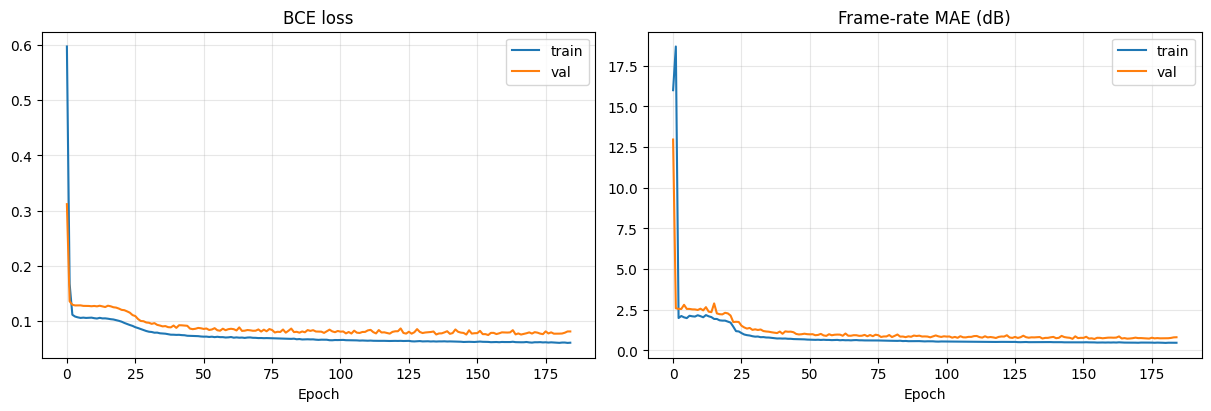

In [9]:
# 7. Plot training curves

metrics_path = RUN_DIR / "csv" / "metrics.csv"
assert metrics_path.is_file(), f"No metrics file found: {metrics_path}"

metrics = pd.read_csv(metrics_path)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for col, ax, title in [
    ("loss", axes[0], "BCE loss"),
    ("mae_db", axes[1], "Frame-rate MAE (dB)"),
]:
    for split in ["train", "val"]:
        metric = f"{col}/{split}"
        if metric in metrics.columns:
            rows = metrics[["epoch", metric]].dropna()
            if not rows.empty:
                ax.plot(rows["epoch"], rows[metric], label=split)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.show()

Loading: /content/drive/Othercomputers/MacBook Air/data/gr_pred_runs/s6_gr_20260525_181724_s6_v1_discretized_fixed_v3/checkpoints/best-154-16430.ckpt


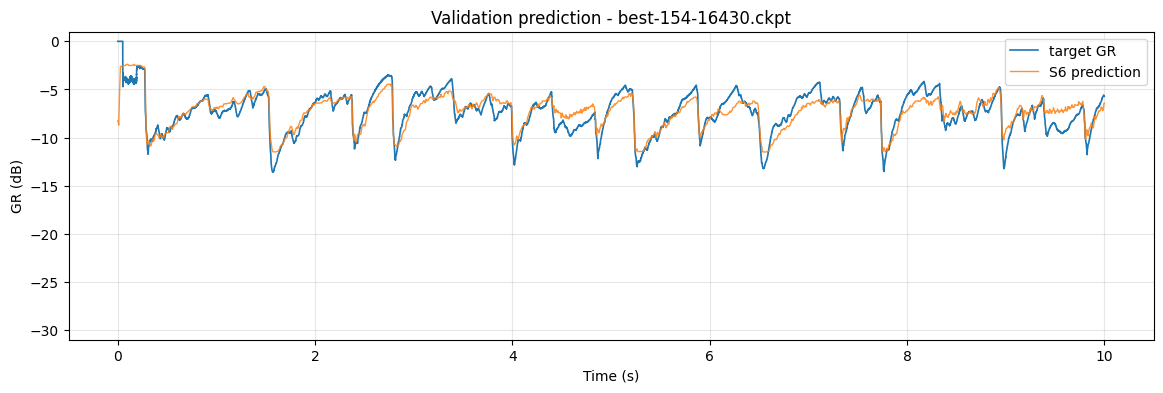

In [10]:
# 8. Quick validation prediction plot


def _checkpoint_sort_key(path: Path):
    match = re.match(r"(?:best|epoch)-(\d+)(?:-(\d+))?", path.stem)
    if match:
        return int(match.group(1)), int(match.group(2) or -1), path.stat().st_mtime
    return -1, -1, path.stat().st_mtime


def latest_best_checkpoint(run_dir: Path) -> Path:
    ckpt_dir = run_dir / "checkpoints"
    best_files = sorted(ckpt_dir.glob("best-*.ckpt"), key=_checkpoint_sort_key)
    if best_files:
        return best_files[-1]
    last = ckpt_dir / "last.ckpt"
    if last.is_file():
        return last
    ckpts = sorted(ckpt_dir.glob("*.ckpt"), key=_checkpoint_sort_key)
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints in {ckpt_dir}")
    return ckpts[-1]

best_path = ""
if "best_cb" in globals() and getattr(best_cb, "best_model_path", ""):
    best_path = best_cb.best_model_path
ckpt_path = Path(best_path) if best_path else latest_best_checkpoint(RUN_DIR)
print(f"Loading: {ckpt_path}")

with open(RUN_DIR / "hparams.json") as f:
    hp = json.load(f)

model_for_eval = build_frame_rate_s6_from_hparams(hp)
system_eval = DiscretizedGRPredictionSystem.load_from_checkpoint(
    str(ckpt_path),
    model=model_for_eval,
    map_location="cpu",
)
system_eval.eval()

if not hasattr(dm, "val_dataset"):
    dm.setup("fit")

batch = next(iter(dm.val_dataloader()))
dry, gr_db = batch
with torch.no_grad():
    logits = system_eval(dry)
    pred_db = system_eval.model.to_db(logits, samples=dry.shape[-1])

seconds_to_plot = 20
n = min(dry.shape[-1], seconds_to_plot * SAMPLE_RATE)
time = torch.arange(n) / SAMPLE_RATE

plt.figure(figsize=(14, 4))
plt.plot(time, gr_db[0, 0, :n], label="target GR", linewidth=1.2)
plt.plot(time, pred_db[0, 0, :n], label="S6 prediction", linewidth=1.0, alpha=0.85)
plt.ylim(GR_DB_MIN - 1, 1)
plt.xlabel("Time (s)")
plt.ylabel("GR (dB)")
plt.title(f"Validation prediction - {ckpt_path.name}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()